# Problem Statement

"""
This project aims to explore the relationship between a country's economic performance,
income inequality, and overall happiness levels.

By combining data from the World Happiness Report, GDP per capita (World Bank),
and the Gini Index (income inequality), this analysis seeks to answer the following question:

Research Question:
Does income inequality (Gini Index) affect happiness levels even in countries with high GDP per capita?

This project will involve gathering, assessing, cleaning, and merging multiple datasets
to perform an exploratory data analysis and uncover meaningful insights.
"""

# 1- Data Gathering

In [3]:
import pandas as pd

happiness = pd.read_csv('data/raw/2019.csv')
gdp = pd.read_csv('data/raw/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv', skiprows=4) #skip the first 4 rows which contain metadata
# Preview datasets  
print("Happiness Dataset:")
display(happiness.head())

print("\nGDP Dataset:")
display(gdp.head())


Happiness Dataset:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298



GDP Dataset:


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


### Dataset 1: World Happiness Report

This dataset was selected because it directly measures happiness levels across countries, which is the main target variable in this project. It allows us to analyze how different factors influence overall well-being.

The dataset was downloaded manually as a CSV file.

Key variables include:
- Country: identifies each country
- Score: represents the happiness level
- GDP per capita: economic contribution to happiness
- Social support, life expectancy, and freedom: factors influencing happiness

### Dataset 2: GDP per Capita (World Bank)

This dataset was chosen to represent the economic performance of each country, which is a key factor in analyzing happiness levels.

The dataset was gathered manually from the World Bank.

Key variables include:
- Country Name: identifies each country
- Year: represents the time dimension
- GDP per capita: measures economic output per person

In [4]:
import requests
import zipfile
import io

# URL for Gini dataset
url = "http://api.worldbank.org/v2/en/indicator/SI.POV.GINI?downloadformat=csv"

# download the file
response = requests.get(url)

# unzip the file
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall("data/raw")

print("Gini dataset downloaded and extracted!")

Gini dataset downloaded and extracted!


In [ ]:
# TEST
assert gdp.shape[0] > 0
assert gini.shape[0] > 0
assert happiness.shape[0] > 0
print("Datasets loaded successfully")

NameError: name 'Gini' is not defined

### Dataset 3: Gini Index (World Bank)

This dataset was selected to measure income inequality, which is essential for analyzing its effect on happiness.

The dataset was gathered programmatically from the World Bank.

Key variables include:
- Country Name: identifies each country
- Year: represents the time dimension
- Gini Index: measures income inequality within a country

In [4]:
gini=pd.read_csv('data/raw/API_SI.POV.GINI_DS2_en_csv_v2_47.csv', skiprows=4) #skip the first 4 rows which contain metadata
gini.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2- Data Assessment

In [5]:
print("Happiness Info:")
happiness.info()

Happiness Info:
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


In [6]:
print("GDP Info:")
gdp.info()

GDP Info:
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    floa

In [7]:
print("Gini Info:")
gini.info()

Gini Info:
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            1 non-null      float64
 8   1964            1 non-null      float64
 9   1965            1 non-null      float64
 10  1966            1 non-null      float64
 11  1967            1 non-null      float64
 12  1968            2 non-null      float64
 13  1969            2 non-null      float64
 14  1970            3 non-null      float64
 15  1971            3 non-null      float64
 16  1972            2 non-null      float64
 17  1973            3 non-null      flo

In [8]:
print("Missing Values for happiness dataset:")
print(happiness.isnull().sum())
print("\nMissing Values for GDP dataset:")
print(gdp.isnull().sum())   
print("\nMissing Values for Gini dataset:")
print(gini.isnull().sum())

Missing Values for happiness dataset:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Missing Values for GDP dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
                 ... 
2022                9
2023               15
2024               26
2025              266
Unnamed: 70       266
Length: 71, dtype: int64

Missing Values for Gini dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2022              197
2023              213
2024              253
2025              266
Unnamed: 70       266
Length: 71, dtype: int64


### Data Quality Issues

1. **Missing Values in GDP and Gini datasets**
   - The GDP and Gini datasets contain a significant number of missing values across many years.
   - For example, some columns (e.g., 2025) have completely missing values.
   - This affects the completeness of the data and may lead to inaccurate analysis if not handled properly.

2. **Irrelevant / Empty Column (Unnamed: 70)**
   - Both GDP and Gini datasets contain an extra column named "Unnamed: 70".
   - This column contains only null values and does not provide any useful information.
   - It should be removed during the cleaning phase.

---

### Data Tidiness Issues

1. **Years Stored as Columns Instead of Rows**
   - In both GDP and Gini datasets, each year is stored as a separate column (1960–2025).
   - This violates the tidiness rule that each variable should form a column.
   - The data should be reshaped into a long format with columns such as: Country, Year, Value.

2. **Data Split Across Multiple Tables**
   - The data is distributed across three separate datasets (Happiness, GDP, Gini).
   - Each dataset contains related information about countries.
   - This violates the rule that each type of observational unit should form a single table.
   - These datasets need to be merged into one final dataset for analysis.

# 3- Data Assessment

### Removing Irrelevant Columns

The GDP and Gini datasets contain an unnecessary column named "Unnamed: 70", which consists entirely of missing values.

This column does not contribute any meaningful information to the analysis and will be removed as part of the data cleaning process to improve data quality.

In [9]:
# Drop unnecessary columns

gdp.drop(columns=['Unnamed: 70'], inplace=True)
gini.drop(columns=['Unnamed: 70'], inplace=True)

#checking validation
print("after dropping unnecessary columns, GDP dataset:")
display(gdp.head())
print("\n after dropping unnecessary columns, Gini dataset:")
display(gini.head())

after dropping unnecessary columns, GDP dataset:


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN



 after dropping unnecessary columns, Gini dataset:


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Reshaping Data from Wide Format to Long Format

In the GDP and Gini datasets, each year is stored as a separate column. This structure violates the data tidiness principle that each variable should have its own column.

To fix this issue, the datasets are transformed into a long format using the melt function, where years are converted into a single column called "Year", and their corresponding values are stored in "GDP" and "Gini" columns.

In [19]:
# Reshape GDP dataset
gdp_melted = gdp.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='GDP'
)

# Reshape Gini dataset
gini_melted = gini.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)

In [20]:
# checking validation
print("After reshaping, GDP dataset:")
display(gdp_melted.head())

print("\nAfter reshaping, Gini dataset:")
display(gini_melted.head())

After reshaping, GDP dataset:


,Country Name,Country Code,Indicator Name,Indicator Code,Year,GDP
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.089204
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,121.936832
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN



After reshaping, Gini dataset:


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Gini
0,Aruba,ABW,Gini index,SI.POV.GINI,1960,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,1960,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,1960,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,1960,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,1960,NaN


### Converting Year Column to Numeric Type

After reshaping, the "Year" column is stored as a string. Converting it to a numeric format allows for easier filtering and analysis based on specific years.

In [21]:
# Convert Year to numeric to facilitate filtering and merging and avoid issues with string comparisons
gdp_melted['Year'] = pd.to_numeric(gdp_melted['Year'], errors='coerce')
gini_melted['Year'] = pd.to_numeric(gini_melted['Year'], errors='coerce')

In [24]:
gdp_melted.info()
gini_melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    17556 non-null  str    
 1   Country Code    17556 non-null  str    
 2   Indicator Name  17556 non-null  str    
 3   Indicator Code  17556 non-null  str    
 4   Year            17556 non-null  int64  
 5   GDP             14561 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 823.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    17556 non-null  str    
 1   Country Code    17556 non-null  str    
 2   Indicator Name  17556 non-null  str    
 3   Indicator Code  17556 non-null  str    
 4   Year            17556 non-null  int64  
 5   Gini            2402 non-null   float64
dtypes: float64(1), int64(

### Filtering and Validating GDP and Gini Data

The GDP dataset is filtered to 2019 to match the year of the Happiness dataset. Rows with missing GDP values are removed to ensure complete economic data.

For the Gini dataset, missing values are removed first. Then, the most recent available Gini value for each country is retained because inequality data is not available for every country in 2019.

After each step, validation checks are performed to confirm that the cleaning was successful.

In [25]:
# Filter GDP for 2019 to match the Happiness dataset
gdp_2019 = gdp_melted[gdp_melted['Year'] == 2019].copy()
gdp_2019 = gdp_2019.dropna(subset=['GDP'])

# Validation for GDP filtering
print("GDP unique years after filtering:", gdp_2019['Year'].unique())
print("Missing GDP values after cleaning:", gdp_2019['GDP'].isnull().sum())
display(gdp_2019.head())

GDP unique years after filtering: [2019]
Missing GDP values after cleaning: 0


,Country Name,Country Code,Indicator Name,Indicator Code,Year,GDP
15694,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,30645.890602
15695,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,1507.085600
15696,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,496.602504
15697,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,2216.385055
15698,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,2493.678844


In [26]:
# Handle Gini by keeping the most recent available value for each country
gini_melted = gini_melted.dropna(subset=['Gini']).copy()

gini_melted = gini_melted.sort_values(
    ['Country Name', 'Year'],
    ascending=[True, False]
)

gini_final = gini_melted.drop_duplicates(
    subset='Country Name',
    keep='first'
).copy()

# Validation for Gini cleaning
print("Missing Gini values after cleaning:", gini_final['Gini'].isnull().sum())
print("Duplicate countries after cleaning:", gini_final['Country Name'].duplicated().sum())
display(gini_final.head())

Missing Gini values after cleaning: 0
Duplicate countries after cleaning: 0


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Gini
15965,Albania,ALB,Gini index,SI.POV.GINI,2020,29.4
13626,Algeria,DZA,Gini index,SI.POV.GINI,2011,27.6
15432,Angola,AGO,Gini index,SI.POV.GINI,2018,51.3
17033,Argentina,ARG,Gini index,SI.POV.GINI,2024,42.4
16768,Armenia,ARM,Gini index,SI.POV.GINI,2023,27.2


### Standardizing Column Names for Merging

The country column has different names across datasets (e.g., "Country Name" vs "Country or region"). To enable merging, column names are standardized to "Country".

In [28]:
# Rename columns for merging
gdp_2019.rename(columns={'Country Name': 'Country'}, inplace=True)
gini_final.rename(columns={'Country Name': 'Country'}, inplace=True)

happiness.rename(columns={'Country or region': 'Country'}, inplace=True)
display(gdp_2019.head())
display(gini_final.head())

,Country,Country Code,Indicator Name,Indicator Code,Year,GDP
15694,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,30645.890602
15695,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,1507.085600
15696,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,496.602504
15697,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,2216.385055
15698,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,2019,2493.678844


,Country,Country Code,Indicator Name,Indicator Code,Year,Gini
15965,Albania,ALB,Gini index,SI.POV.GINI,2020,29.4
13626,Algeria,DZA,Gini index,SI.POV.GINI,2011,27.6
15432,Angola,AGO,Gini index,SI.POV.GINI,2018,51.3
17033,Argentina,ARG,Gini index,SI.POV.GINI,2024,42.4
16768,Armenia,ARM,Gini index,SI.POV.GINI,2023,27.2


### Merging the Datasets

The cleaned datasets are merged into a single dataset using the "Country" column. This allows combining economic performance (GDP), income inequality (Gini), and happiness scores into one unified dataset for analysis.

In [30]:
# Merge datasets
merged = happiness.merge(gdp_2019[['Country', 'GDP']], on='Country')
merged = merged.merge(gini_final[['Country', 'Gini']], on='Country')

# preview
merged.head()

,Overall rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,GDP,Gini
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,48358.180777,27.4
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,59404.266325,29.9
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,76430.588947,26.5
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,69296.314436,26.8
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,53554.900749,25.7


### Saving the Cleaned Dataset

The final cleaned dataset is saved locally for future analysis and visualization. This step ensures that both raw and processed data are preserved.

In [31]:
# Save cleaned data
merged.drop(columns=['GDP per capita'], inplace=True)
merged.to_csv('data/cleaned/cleaned_data.csv', index=False)
# The GDP per capita column in the Happiness dataset was removed because it represents a normalized value used in calculating the happiness score. 
#Instead, the GDP data from the World Bank dataset is used as it reflects the actual economic value.

# 4- Exploratory Data Analysis (EDA)

In this section, we explore the relationships between GDP per capita, income inequality (Gini Index), and happiness scores across countries.

The main objective is to answer the research question:
**Does income inequality affect happiness levels even in countries with high GDP per capita?**

Through visualizations, we aim to identify patterns, correlations, and potential insights that explain how economic wealth and income distribution contribute to overall well-being.

This analysis will help determine whether higher economic performance alone is sufficient for higher happiness, or if income equality also plays a significant role.

### 1- Relationship Between GDP per Capita and Happiness

This scatter plot examines the relationship between a country's economic performance (GDP per capita) and its happiness score.

We expect that countries with higher GDP per capita tend to have higher happiness levels. 
However, this visualization also helps identify whether this relationship is consistent across all countries or if there are exceptions.

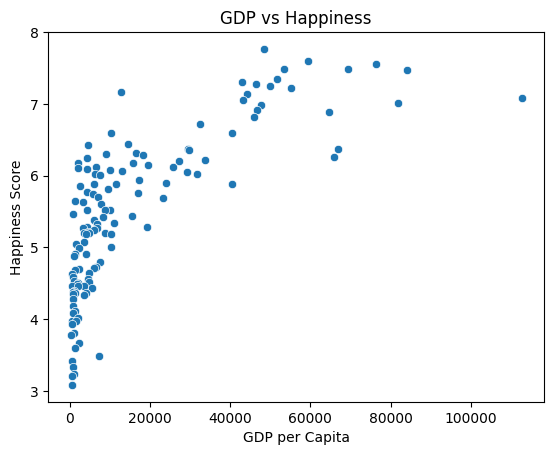

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='GDP', y='Score', data=merged)
plt.title('GDP vs Happiness')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

The scatter plot shows a clear positive relationship between GDP per capita and happiness. 
Countries with higher GDP tend to have higher happiness scores.

However, the relationship is not perfectly linear, indicating that factors beyond economic wealth—such as income inequality—may also influence happiness levels.

### 2- Relationship Between Income Inequality and Happiness

This plot explores how income inequality, measured by the Gini Index, affects happiness levels across countries.

A higher Gini Index indicates greater income inequality. 
This visualization helps determine whether countries with more unequal income distribution tend to have lower happiness scores.

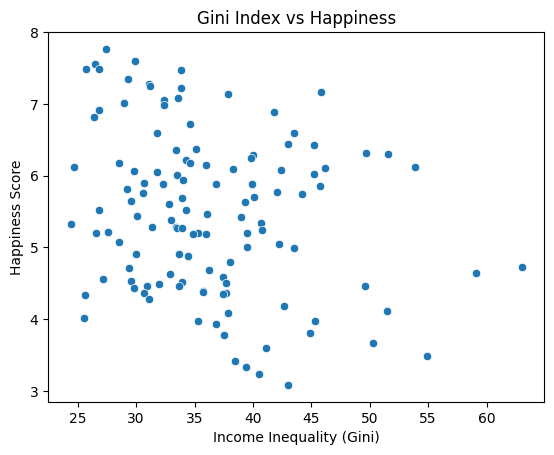

In [21]:
# convert Gini to numeric (force errors to NaN)
merged['Gini'] = pd.to_numeric(merged['Gini'], errors='coerce')

# remove rows with invalid values
merged = merged.dropna(subset=['Gini'])
sns.scatterplot(x='Gini', y='Score', data=merged)
plt.title('Gini Index vs Happiness')
plt.xlabel('Income Inequality (Gini)')
plt.ylabel('Happiness Score')
plt.show()


The scatter plot shows a general negative relationship between income inequality and happiness.

Countries with lower Gini Index values (more equal income distribution) tend to have higher happiness scores, while countries with higher inequality tend to have lower happiness.

Although the relationship is not perfectly linear, the overall trend suggests that income inequality negatively impacts well-being.

### 3- Correlation Analysis Between Variables

This heatmap shows the correlation between GDP per capita, Gini Index, and happiness score.

Correlation values range from -1 to 1:
- Values close to 1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate little or no relationship.

This visualization helps summarize how strongly these variables are related to each other.

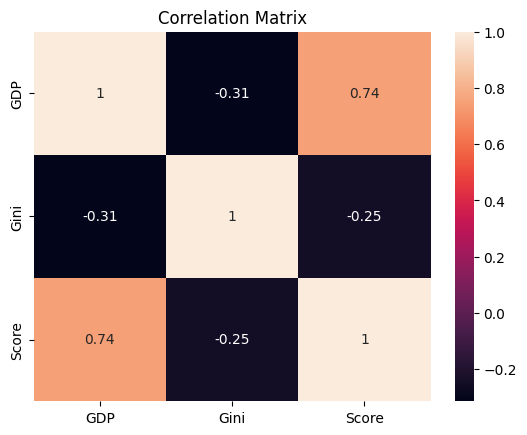

In [22]:
corr = merged[['GDP', 'Gini', 'Score']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()



The correlation matrix provides a numerical summary of the relationships between GDP per capita, Gini Index, and happiness score.

- GDP and happiness show a strong positive correlation (0.74), indicating that higher economic performance is associated with higher happiness levels.
- Gini Index and happiness show a negative correlation (-0.25), suggesting that higher income inequality is linked to lower happiness.
- GDP and Gini also show a negative correlation (-0.31), indicating that wealthier countries tend to have lower income inequality.

Overall, GDP appears to have the strongest influence on happiness, but income inequality still plays a noticeable role.

## Final Answer to the Research Question

The analysis shows that GDP per capita has a strong positive relationship with happiness, indicating that countries with higher economic performance tend to have higher happiness scores.

However, income inequality, measured by the Gini Index, also plays an important role. The results show a negative relationship between Gini and happiness, meaning that countries with higher inequality tend to have lower happiness levels.

Although GDP appears to be the strongest factor, it is not sufficient on its own. The findings suggest that both economic wealth and fair income distribution are important for improving overall well-being.

Therefore, income inequality does affect happiness, even in countries with high GDP per capita.

### Reflection

During this project, I worked with multiple real-world datasets that required significant cleaning and restructuring. One of the main challenges was handling missing values in the Gini dataset, as inequality data is not consistently reported every year for all countries.

To address this, I used the most recent available value for each country, which improved data coverage and allowed for a more meaningful analysis.

If I had more time, I would explore additional factors such as education, healthcare, or political stability, and possibly use more advanced statistical methods to better understand the relationships between variables.

### Conclusion

This project demonstrates that while economic performance (GDP per capita) is strongly associated with higher happiness levels, it is not the only determining factor.

Income inequality also plays a meaningful role, as countries with more equal income distribution tend to report higher happiness scores.

Overall, achieving higher levels of well-being requires not only economic growth but also fair distribution of resources.